In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import os
import json
import shutil
import random
import struct

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("\nLibraries loaded successfully.")

TensorFlow version: 2.20.0
NumPy version: 2.0.2

Libraries loaded successfully.


In [5]:
DATA_PATH = (
    "/content/drive/MyDrive/"
    "Bridge_SHM_TinyML/data/"
    "final_bridge_SHM_large_1000experiments.csv"
)

print("Dataset path:")
print(DATA_PATH)

print("\nFile exists:", os.path.exists(DATA_PATH))

Dataset path:
/content/drive/MyDrive/Bridge_SHM_TinyML/data/final_bridge_SHM_large_1000experiments.csv

File exists: True


In [6]:
MODEL_DIR = (
    "/content/drive/MyDrive/"
    "Bridge_SHM_TinyML/model_artifacts_final"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

print("Model artifact directory:")
print(MODEL_DIR)

Model artifact directory:
/content/drive/MyDrive/Bridge_SHM_TinyML/model_artifacts_final


In [9]:
df = pd.read_csv(
    DATA_PATH
)

print("Dataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

Dataset shape:
(200000, 21)

First 5 rows:


,experiment_id,node_id,timestamp_utc,condition,rest,load,vibration,load_kg,vibration_level,damage_severity,...,mpu_y_g,mpu_z_g,adxl_x_g,adxl_y_g,adxl_z_g,temperature_c,humidity_pct,strain_microstrain,bridge_health_status,damage_label
0,DB_0501,NODE_01,2027-05-17 00:00:00+00:00,high_load,no,yes,no,703.834014,0.177035,0.6778,...,0.032776,1.025608,0.060913,0.068091,0.958720,40.570824,57.219083,92.623248,damaged,1
1,DB_0501,NODE_01,2027-05-17 00:00:00.020000+00:00,high_load,no,yes,no,703.834014,0.177035,0.6778,...,0.040902,1.033809,0.103848,0.066428,0.982409,40.708901,57.243601,96.226449,damaged,1
2,DB_0501,NODE_01,2027-05-17 00:00:00.040000+00:00,high_load,no,yes,no,703.834014,0.177035,0.6778,...,0.043681,1.041399,0.094799,0.052489,1.000815,40.798660,57.265246,98.636980,damaged,1
3,DB_0501,NODE_01,2027-05-17 00:00:00.060000+00:00,high_load,no,yes,no,703.834014,0.177035,0.6778,...,0.042313,1.040907,0.104850,0.063375,0.989829,40.609639,57.450913,102.685854,damaged,1
4,DB_0501,NODE_01,2027-05-17 00:00:00.080000+00:00,high_load,no,yes,no,703.834014,0.177035,0.6778,...,0.055637,1.026783,0.165817,0.075736,1.020607,40.580708,57.354615,99.713308,damaged,1



Columns:
['experiment_id', 'node_id', 'timestamp_utc', 'condition', 'rest', 'load', 'vibration', 'load_kg', 'vibration_level', 'damage_severity', 'mpu_x_g', 'mpu_y_g', 'mpu_z_g', 'adxl_x_g', 'adxl_y_g', 'adxl_z_g', 'temperature_c', 'humidity_pct', 'strain_microstrain', 'bridge_health_status', 'damage_label']


In [10]:
print("Number of experiments:")
print(
    df["experiment_id"].nunique()
)

print("\nNodes:")
print(
    sorted(df["node_id"].unique())
)

print("\nSamples per experiment/node:")

display(
    df.groupby(
        ["experiment_id", "node_id"]
    ).size()
    .value_counts()
    .sort_index()
)

print("\nHealth distribution:")
print(
    df[
        ["experiment_id", "bridge_health_status"]
    ]
    .drop_duplicates()
    ["bridge_health_status"]
    .value_counts()
)

print("\nMissing values:")
display(
    df.isnull().sum()
)

Number of experiments:
1000

Nodes:
['NODE_01', 'NODE_02']

Samples per experiment/node:


,count
100,2000



Health distribution:
bridge_health_status
damaged    500
healthy    500
Name: count, dtype: int64

Missing values:


,0
experiment_id,0
node_id,0
timestamp_utc,0
condition,0
rest,0
load,0
vibration,0
load_kg,0
vibration_level,0
damage_severity,0


In [11]:
EXPECTED_SAMPLES_PER_WINDOW = 100
EXPECTED_NODES = 2
EXPECTED_EXPERIMENTS = 1000

assert (
    df["experiment_id"].nunique()
    == EXPECTED_EXPERIMENTS
), "Unexpected number of experiments."

assert (
    df["node_id"].nunique()
    == EXPECTED_NODES
), "Unexpected number of nodes."

samples_per_group = (
    df.groupby(
        ["experiment_id", "node_id"]
    ).size()
)

assert (
    samples_per_group.nunique() == 1
), "Not all experiment/node groups have equal samples."

assert (
    samples_per_group.iloc[0]
    == EXPECTED_SAMPLES_PER_WINDOW
), "Expected exactly 100 samples per window."

print("✅ Dataset structure validated.")
print(
    f"Experiments: {df['experiment_id'].nunique()}"
)
print(
    f"Nodes: {df['node_id'].nunique()}"
)
print(
    f"Samples/window: {samples_per_group.iloc[0]}"
)

✅ Dataset structure validated.
Experiments: 1000
Nodes: 2
Samples/window: 100


In [13]:
df["timestamp_utc"] = pd.to_datetime(
    df["timestamp_utc"],
    utc=True,
    format='ISO8601'
)

df = df.sort_values(
    [
        "experiment_id",
        "node_id",
        "timestamp_utc"
]
).reset_index(drop=True)

print("✅ Dataset sorted chronologically.")

✅ Dataset sorted chronologically.


In [14]:
label_map = {
    "healthy": 0,
    "damaged": 1
}

df["damage_label"] = (
    df["bridge_health_status"]
    .map(label_map)
)

assert (
    df["damage_label"].notna().all()
), "Unknown health label detected."

print(
    df[
        [
            "bridge_health_status",
            "damage_label"
        ]
    ]
    .drop_duplicates()
    .sort_values("damage_label")
)

       bridge_health_status  damage_label
100000              healthy             0
0                   damaged             1


In [15]:
time_diffs = (
    df
    .groupby(
        ["experiment_id", "node_id"]
    )["timestamp_utc"]
    .diff()
    .dt.total_seconds()
    .dropna()
)

median_dt = time_diffs.median()

SAMPLE_RATE_HZ = 1.0 / median_dt

print(
    f"Median sample interval: "
    f"{median_dt:.6f} seconds"
)

print(
    f"Estimated sampling rate: "
    f"{SAMPLE_RATE_HZ:.2f} Hz"
)

Median sample interval: 0.020000 seconds
Estimated sampling rate: 50.00 Hz


In [16]:
SAMPLE_RATE_HZ = 50
WINDOW_SIZE = 100

WINDOW_DURATION_SEC = (
    WINDOW_SIZE / SAMPLE_RATE_HZ
)

print("TinyML window specification")
print("----------------------------")
print("Sampling rate :", SAMPLE_RATE_HZ, "Hz")
print("Window size   :", WINDOW_SIZE, "samples")
print(
    "Duration      :",
    WINDOW_DURATION_SEC,
    "seconds"
)

TinyML window specification
----------------------------
Sampling rate : 50 Hz
Window size   : 100 samples
Duration      : 2.0 seconds


In [17]:
def calculate_rms(values):

    values = np.asarray(
        values,
        dtype=np.float64
    )

    return np.sqrt(
        np.mean(values ** 2)
    )


def calculate_std(values):

    values = np.asarray(
        values,
        dtype=np.float64
    )

    mean = np.mean(values)

    return np.sqrt(
        np.mean(
            (values - mean) ** 2
        )
    )


def calculate_ptp(values):

    values = np.asarray(
        values,
        dtype=np.float64
    )

    return (
        np.max(values)
        - np.min(values)
    )

In [18]:
def extract_features(window):

    features = {}

    # =====================================================
    # MPU9250
    # 3 axes × 4 features = 12
    # =====================================================

    for axis in ["x", "y", "z"]:

        column = f"mpu_{axis}_g"

        values = window[column].to_numpy(
            dtype=np.float64
        )

        features[
            f"mpu_{axis}_mean"
        ] = np.mean(values)

        features[
            f"mpu_{axis}_std"
        ] = calculate_std(values)

        features[
            f"mpu_{axis}_rms"
        ] = calculate_rms(values)

        features[
            f"mpu_{axis}_ptp"
        ] = calculate_ptp(values)


    # =====================================================
    # ADXL335
    # 3 axes × 4 features = 12
    # =====================================================

    for axis in ["x", "y", "z"]:

        column = f"adxl_{axis}_g"

        values = window[column].to_numpy(
            dtype=np.float64
        )

        features[
            f"adxl_{axis}_mean"
        ] = np.mean(values)

        features[
            f"adxl_{axis}_std"
        ] = calculate_std(values)

        features[
            f"adxl_{axis}_rms"
        ] = calculate_rms(values)

        features[
            f"adxl_{axis}_ptp"
        ] = calculate_ptp(values)


    # =====================================================
    # STRAIN
    # 3 features
    # =====================================================

    strain = (
        window[
            "strain_microstrain"
        ]
        .to_numpy(dtype=np.float64)
    )

    features["strain_mean"] = (
        np.mean(strain)
    )

    features["strain_std"] = (
        calculate_std(strain)
    )

    features["strain_ptp"] = (
        calculate_ptp(strain)
    )


    # =====================================================
    # TEMPERATURE
    # 1 feature
    # =====================================================

    temperature = (
        window["temperature_c"]
        .to_numpy(dtype=np.float64)
    )

    features["temperature_mean"] = (
        np.mean(temperature)
    )


    # =====================================================
    # HUMIDITY
    # 1 feature
    # =====================================================

    humidity = (
        window["humidity_pct"]
        .to_numpy(dtype=np.float64)
    )

    features["humidity_mean"] = (
        np.mean(humidity)
    )


    return features

In [19]:
FEATURE_NAMES = [

    # MPU9250
    "mpu_x_mean",
    "mpu_x_std",
    "mpu_x_rms",
    "mpu_x_ptp",

    "mpu_y_mean",
    "mpu_y_std",
    "mpu_y_rms",
    "mpu_y_ptp",

    "mpu_z_mean",
    "mpu_z_std",
    "mpu_z_rms",
    "mpu_z_ptp",

    # ADXL335
    "adxl_x_mean",
    "adxl_x_std",
    "adxl_x_rms",
    "adxl_x_ptp",

    "adxl_y_mean",
    "adxl_y_std",
    "adxl_y_rms",
    "adxl_y_ptp",

    "adxl_z_mean",
    "adxl_z_std",
    "adxl_z_rms",
    "adxl_z_ptp",

    # Strain
    "strain_mean",
    "strain_std",
    "strain_ptp",

    # Environment
    "temperature_mean",
    "humidity_mean"
]

print(
    "Number of features:",
    len(FEATURE_NAMES)
)

for i, name in enumerate(FEATURE_NAMES):
    print(
        f"{i:02d} → {name}"
    )

assert len(FEATURE_NAMES) == 29

Number of features: 29
00 → mpu_x_mean
01 → mpu_x_std
02 → mpu_x_rms
03 → mpu_x_ptp
04 → mpu_y_mean
05 → mpu_y_std
06 → mpu_y_rms
07 → mpu_y_ptp
08 → mpu_z_mean
09 → mpu_z_std
10 → mpu_z_rms
11 → mpu_z_ptp
12 → adxl_x_mean
13 → adxl_x_std
14 → adxl_x_rms
15 → adxl_x_ptp
16 → adxl_y_mean
17 → adxl_y_std
18 → adxl_y_rms
19 → adxl_y_ptp
20 → adxl_z_mean
21 → adxl_z_std
22 → adxl_z_rms
23 → adxl_z_ptp
24 → strain_mean
25 → strain_std
26 → strain_ptp
27 → temperature_mean
28 → humidity_mean


In [20]:
feature_rows = []

for (
    experiment_id,
    node_id
), window in df.groupby(
    [
        "experiment_id",
        "node_id"
    ],
    sort=False
):

    window = window.sort_values(
        "timestamp_utc"
    )

    assert len(window) == WINDOW_SIZE

    features = extract_features(
        window
    )

    # Metadata
    features[
        "experiment_id"
    ] = experiment_id

    features[
        "node_id"
    ] = node_id

    features[
        "bridge_health_status"
    ] = window[
        "bridge_health_status"
    ].iloc[0]

    features[
        "damage_label"
    ] = window[
        "damage_label"
    ].iloc[0]

    features[
        "condition"
    ] = window[
        "condition"
    ].iloc[0]

    feature_rows.append(
        features
    )


feature_df = pd.DataFrame(
    feature_rows
)

print(
    "Feature dataset shape:",
    feature_df.shape
)

display(
    feature_df.head()
)

Feature dataset shape: (2000, 34)


,mpu_x_mean,mpu_x_std,mpu_x_rms,mpu_x_ptp,mpu_y_mean,mpu_y_std,mpu_y_rms,mpu_y_ptp,mpu_z_mean,mpu_z_std,...,strain_mean,strain_std,strain_ptp,temperature_mean,humidity_mean,experiment_id,node_id,bridge_health_status,damage_label,condition
0,0.026153,0.054824,0.060742,0.209692,-0.020495,0.043034,0.047665,0.151949,1.001211,0.029385,...,91.637856,8.136104,34.975993,40.992482,57.888586,DB_0501,NODE_01,damaged,1,high_load
1,0.024334,0.048688,0.054430,0.168298,-0.020361,0.034589,0.040137,0.120669,1.003243,0.024004,...,102.169128,7.857588,34.145937,40.971131,57.834810,DB_0501,NODE_02,damaged,1,high_load
2,0.027568,0.057080,0.063389,0.213122,-0.008740,0.046215,0.047034,0.153709,0.992306,0.031896,...,89.450481,6.981494,27.814501,31.638325,75.816004,DB_0502,NODE_01,damaged,1,high_load
3,0.025818,0.050405,0.056632,0.189890,-0.010340,0.037895,0.039281,0.128003,0.991903,0.026825,...,101.888436,7.795888,31.086268,31.640501,75.787335,DB_0502,NODE_02,damaged,1,high_load
4,0.024827,0.044984,0.051380,0.162747,-0.013899,0.033482,0.036252,0.118962,1.000545,0.023972,...,69.822016,5.483047,22.339486,32.598865,83.986623,DB_0503,NODE_01,damaged,1,normal_load


In [21]:
print(
    "Feature rows:",
    len(feature_df)
)

print(
    "Experiments:",
    feature_df[
        "experiment_id"
    ].nunique()
)

print(
    "Nodes:",
    feature_df[
        "node_id"
    ].nunique()
)

print(
    "Feature count:",
    len(FEATURE_NAMES)
)

missing_features = [
    f
    for f in FEATURE_NAMES
    if f not in feature_df.columns
]

print(
    "\nMissing features:",
    missing_features
)

assert len(feature_df) == 2000
assert len(missing_features) == 0

print(
    "\n✅ Feature dataset validated."
)

Feature rows: 2000
Experiments: 1000
Nodes: 2
Feature count: 29

Missing features: []

✅ Feature dataset validated.


In [22]:
experiment_table = (
    feature_df[
        [
            "experiment_id",
            "damage_label"
        ]
    ]
    .drop_duplicates(
        "experiment_id"
    )
    .reset_index(drop=True)
)

print(
    "Experiments:",
    len(experiment_table)
)

print(
    "\nClass distribution:"
)

print(
    experiment_table[
        "damage_label"
    ].value_counts()
)

Experiments: 1000

Class distribution:
damage_label
1    500
0    500
Name: count, dtype: int64


In [23]:
train_exp, temp_exp = train_test_split(
    experiment_table,
    test_size=0.30,
    stratify=experiment_table[
        "damage_label"
    ],
    random_state=SEED
)

val_exp, test_exp = train_test_split(
    temp_exp,
    test_size=0.50,
    stratify=temp_exp[
        "damage_label"
    ],
    random_state=SEED
)

TRAIN_EXPERIMENTS = set(
    train_exp["experiment_id"]
)

VAL_EXPERIMENTS = set(
    val_exp["experiment_id"]
)

TEST_EXPERIMENTS = set(
    test_exp["experiment_id"]
)

print(
    "Train experiments:",
    len(TRAIN_EXPERIMENTS)
)

print(
    "Validation experiments:",
    len(VAL_EXPERIMENTS)
)

print(
    "Test experiments:",
    len(TEST_EXPERIMENTS)
)

Train experiments: 700
Validation experiments: 150
Test experiments: 150


In [24]:
print(
    "Train ∩ Validation:",
    TRAIN_EXPERIMENTS
    & VAL_EXPERIMENTS
)

print(
    "Train ∩ Test:",
    TRAIN_EXPERIMENTS
    & TEST_EXPERIMENTS
)

print(
    "Validation ∩ Test:",
    VAL_EXPERIMENTS
    & TEST_EXPERIMENTS
)

assert not (
    TRAIN_EXPERIMENTS
    & VAL_EXPERIMENTS
)

assert not (
    TRAIN_EXPERIMENTS
    & TEST_EXPERIMENTS
)

assert not (
    VAL_EXPERIMENTS
    & TEST_EXPERIMENTS
)

print(
    "\n🔥 ZERO EXPERIMENT LEAKAGE."
)

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()

🔥 ZERO EXPERIMENT LEAKAGE.


In [25]:
train_df = feature_df[
    feature_df[
        "experiment_id"
    ].isin(
        TRAIN_EXPERIMENTS
    )
].copy()

val_df = feature_df[
    feature_df[
        "experiment_id"
    ].isin(
        VAL_EXPERIMENTS
    )
].copy()

test_df = feature_df[
    feature_df[
        "experiment_id"
    ].isin(
        TEST_EXPERIMENTS
    )
].copy()

print(
    "Train rows:",
    len(train_df)
)

print(
    "Validation rows:",
    len(val_df)
)

print(
    "Test rows:",
    len(test_df)
)

Train rows: 1400
Validation rows: 300
Test rows: 300


In [26]:
X_train = train_df[
    FEATURE_NAMES
].copy()

y_train = train_df[
    "damage_label"
].to_numpy(
    dtype=np.float32
)

X_val = val_df[
    FEATURE_NAMES
].copy()

y_val = val_df[
    "damage_label"
].to_numpy(
    dtype=np.float32
)

X_test = test_df[
    FEATURE_NAMES
].copy()

y_test = test_df[
    "damage_label"
].to_numpy(
    dtype=np.float32
)

print(
    "X_train:",
    X_train.shape
)

print(
    "X_val:",
    X_val.shape
)

print(
    "X_test:",
    X_test.shape
)

X_train: (1400, 29)
X_val: (300, 29)
X_test: (300, 29)


In [27]:
assert not X_train.isnull().any().any()
assert not X_val.isnull().any().any()
assert not X_test.isnull().any().any()

assert np.isfinite(
    X_train.to_numpy()
).all()

assert np.isfinite(
    X_val.to_numpy()
).all()

assert np.isfinite(
    X_test.to_numpy()
).all()

print(
    "✅ No NaN or infinity detected."
)

✅ No NaN or infinity detected.


In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
)

print(
    "Training mean:",
    np.mean(
        X_train_scaled,
        axis=0
    ).round(5)
)

print(
    "\nTraining std:",
    np.std(
        X_train_scaled,
        axis=0
    ).round(5)
)

Training mean: [-0. -0. -0. -0. -0.  0. -0. -0.  0.  0. -0. -0. -0.  0. -0.  0.  0.  0.
 -0. -0. -0.  0. -0. -0.  0. -0.  0. -0.  0.]

Training std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.]


In [29]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(29,),
        name="sensor_features"
    ),

    tf.keras.layers.Dense(
        16,
        activation="relu",
        name="dense_16"
    ),

    tf.keras.layers.Dense(
        8,
        activation="relu",
        name="dense_8"
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="damage_probability"
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        ),
        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ damage_probability (Dense)      │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 625 (2.44 KB)

 Trainable params: 625 (2.44 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=200,
    batch_size=32,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7421 - auc: 0.8464 - loss: 0.5465 - precision: 0.7917 - recall: 0.6571 - val_accuracy: 0.8800 - val_auc: 0.9493 - val_loss: 0.4026 - val_precision: 0.9385 - val_recall: 0.8133
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8764 - auc: 0.9620 - loss: 0.3344 - precision: 0.9459 - recall: 0.7986 - val_accuracy: 0.8967 - val_auc: 0.9655 - val_loss: 0.2870 - val_precision: 0.9103 - val_recall: 0.8800
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8936 - auc: 0.9692 - loss: 0.2613 - precision: 0.9394 - recall: 0.8414 - val_accuracy: 0.8933 - val_auc: 0.9688 - val_loss: 0.2464 - val_precision: 0.8986 - val_recall: 0.8867
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9050 - auc: 0.9723 - loss: 0.2303 - precision: 0.9328 - recall: 0.8729 - val_accuracy: 0.9000 - val_auc: 0.9709 - val_loss: 0.2281 - val_precision: 0.8947 - val_recall: 0.9067
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━

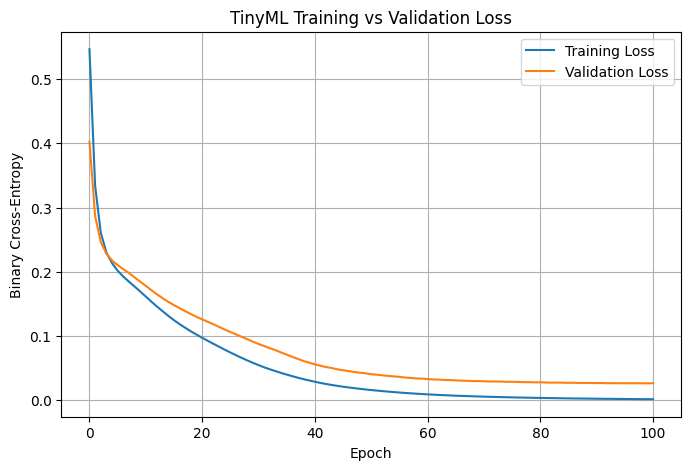

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.title("TinyML Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

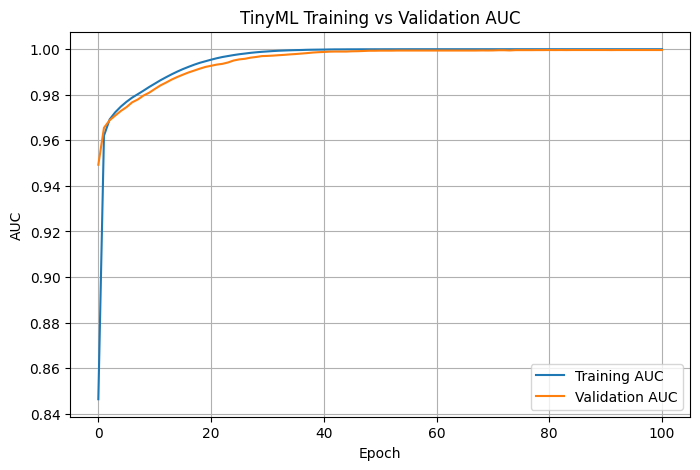

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["auc"],
    label="Training AUC"
)

plt.plot(
    history.history["val_auc"],
    label="Validation AUC"
)

plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("TinyML Training vs Validation AUC")
plt.legend()
plt.grid(True)

plt.show()

In [33]:
test_results = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

for name, value in zip(
    model.metrics_names,
    test_results
):

    print(
        f"{name}: {value:.4f}"
    )

loss: 0.0266
compile_metrics: 0.9967


In [34]:
test_damage_probability = (
    model.predict(
        X_test_scaled,
        verbose=0
    ).reshape(-1)
)

test_predictions = (
    test_damage_probability >= 0.5
).astype(int)

print(
    "First 10 damage probabilities:"
)

print(
    test_damage_probability[:10]
)

First 10 damage probabilities:
[1.         1.         0.99817705 0.95546824 1.         0.99999934
 1.         1.         1.         1.        ]


In [35]:
test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_auc = roc_auc_score(
    y_test,
    test_damage_probability
)

print(
    f"Accuracy : {test_accuracy:.4f}"
)

print(
    f"Precision: {test_precision:.4f}"
)

print(
    f"Recall   : {test_recall:.4f}"
)

print(
    f"F1       : {test_f1:.4f}"
)

print(
    f"ROC-AUC  : {test_auc:.4f}"
)

Accuracy : 0.9967
Precision: 1.0000
Recall   : 0.9933
F1       : 0.9967
ROC-AUC  : 0.9991


In [36]:
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "Healthy",
            "Damaged"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Healthy       0.99      1.00      1.00       150
     Damaged       1.00      0.99      1.00       150

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



[[150   0]
 [  1 149]]


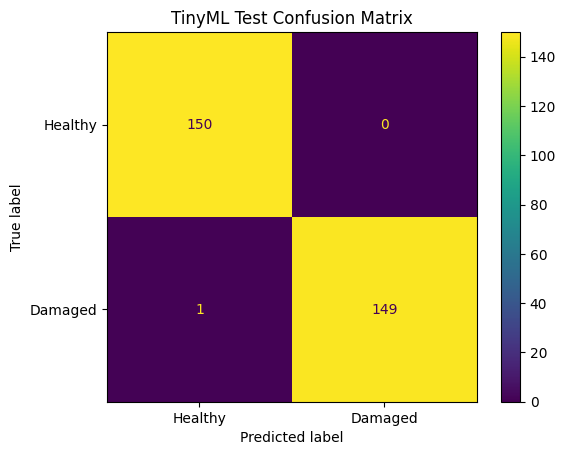

In [37]:
cm = confusion_matrix(
    y_test,
    test_predictions
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Healthy",
        "Damaged"
    ]
)

disp.plot()

plt.title(
    "TinyML Test Confusion Matrix"
)

plt.show()

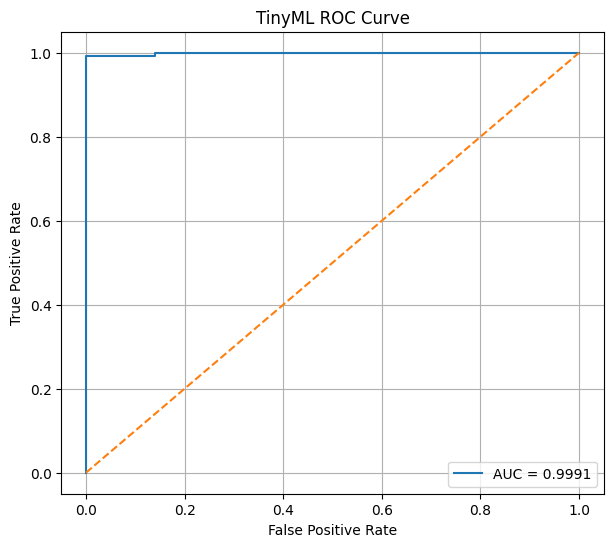

In [38]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    test_damage_probability
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {test_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "TinyML ROC Curve"
)

plt.legend()
plt.grid(True)

plt.show()

In [40]:
results_df = test_df[
    [
        "experiment_id",
        "node_id",
        "condition",
        "damage_label"
    ]
].copy()

results_df[
    "damage_probability_pct"
] = (
    test_damage_probability * 100
)

results_df[
    "tinyml_health_pct"
] = (
    100
    - results_df[
        "damage_probability_pct"
    ]
)

results_df[
    "predicted_state"
] = np.where(
    results_df[
        "damage_probability_pct"
    ] >= 50,

    "DAMAGED",

    "HEALTHY"
)

display(
    results_df.head(200)
)

,experiment_id,node_id,condition,damage_label,damage_probability_pct,tinyml_health_pct,predicted_state
22,DB_0512,NODE_01,normal_load,1,100.000000,0.000000,DAMAGED
23,DB_0512,NODE_02,normal_load,1,100.000000,0.000000,DAMAGED
24,DB_0513,NODE_01,normal_load,1,99.817703,0.182297,DAMAGED
25,DB_0513,NODE_02,normal_load,1,95.546822,4.453178,DAMAGED
30,DB_0516,NODE_01,vibration,1,100.000000,0.000000,DAMAGED
...,...,...,...,...,...,...,...
1339,HB_0170,NODE_02,normal_load,0,0.002500,99.997498,HEALTHY
1342,HB_0172,NODE_01,normal_load,0,0.000026,99.999977,HEALTHY
1343,HB_0172,NODE_02,normal_load,0,0.000002,100.000000,HEALTHY
1348,HB_0175,NODE_01,rest,0,0.219509,99.780495,HEALTHY


In [41]:
keras_path = os.path.join(
    MODEL_DIR,
    "shm_tinyml_final.keras"
)

model.save(
    keras_path
)

print(
    "Saved:",
    keras_path
)

Saved: /content/drive/MyDrive/Bridge_SHM_TinyML/model_artifacts_final/shm_tinyml_final.keras


In [42]:
import joblib

scaler_path = os.path.join(
    MODEL_DIR,
    "shm_tinyml_scaler.joblib"
)

joblib.dump(
    scaler,
    scaler_path
)

print(
    "Saved:",
    scaler_path
)

Saved: /content/drive/MyDrive/Bridge_SHM_TinyML/model_artifacts_final/shm_tinyml_scaler.joblib


In [43]:
feature_spec = {

    "model_name":
        "Bridge SHM TinyML",

    "model_version":
        "Final_29Feature",

    "sampling_rate_hz":
        SAMPLE_RATE_HZ,

    "window_size":
        WINDOW_SIZE,

    "window_duration_seconds":
        WINDOW_DURATION_SEC,

    "feature_count":
        len(FEATURE_NAMES),

    "feature_names":
        FEATURE_NAMES,

    "label_mapping":
        {
            "healthy": 0,
            "damaged": 1
        },

    "model_architecture":
        [
            29,
            16,
            8,
            1
        ],

    "activation_functions":
        [
            "input",
            "relu",
            "relu",
            "sigmoid"
        ],

    "model_output":
        "damage_probability",

    "health_formula":
        "100 - damage_probability_percent",

    "model_inputs_exclude":
        [
            "experiment_id",
            "node_id",
            "damage_severity"
        ],

    "same_model_all_nodes":
        True
}

spec_path = os.path.join(
    MODEL_DIR,
    "shm_tinyml_feature_spec.json"
)

with open(
    spec_path,
    "w"
) as f:

    json.dump(
        feature_spec,
        f,
        indent=4
    )

print(
    "Saved:",
    spec_path
)

Saved: /content/drive/MyDrive/Bridge_SHM_TinyML/model_artifacts_final/shm_tinyml_feature_spec.json


In [44]:
feature_dataset_path = os.path.join(
    MODEL_DIR,
    "shm_tinyml_29feature_dataset.csv"
)

feature_df.to_csv(
    feature_dataset_path,
    index=False
)

print(
    "Saved:",
    feature_dataset_path
)

Saved: /content/drive/MyDrive/Bridge_SHM_TinyML/model_artifacts_final/shm_tinyml_29feature_dataset.csv


In [45]:
results_path = os.path.join(
    MODEL_DIR,
    "shm_tinyml_test_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print(
    "Saved:",
    results_path
)

Saved: /content/drive/MyDrive/Bridge_SHM_TinyML/model_artifacts_final/shm_tinyml_test_results.csv


In [46]:
converter = tf.lite.TFLiteConverter.from_keras_model(
    model
)

tflite_float_model = (
    converter.convert()
)

float_tflite_path = os.path.join(
    MODEL_DIR,
    "shm_tinyml_float32.tflite"
)

with open(
    float_tflite_path,
    "wb"
) as f:

    f.write(
        tflite_float_model
    )

print(
    "Float32 TFLite size:",
    len(tflite_float_model),
    "bytes"
)

print(
    "Saved:",
    float_tflite_path
)

Saved artifact at '/tmp/tmplgin7fmu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 29), dtype=tf.float32, name='sensor_features')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139858572085968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139858572087120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139858572085776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139858572083856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139858572087696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139858572084048: TensorSpec(shape=(), dtype=tf.resource, name=None)
Float32 TFLite size: 4608 bytes
Saved: /content/drive/MyDrive/Bridge_SHM_TinyML/model_artifacts_final/shm_tinyml_float32.tflite


In [47]:
def representative_dataset():

    sample_count = min(
        500,
        len(X_train_scaled)
    )

    indices = np.linspace(
        0,
        len(X_train_scaled) - 1,
        sample_count,
        dtype=int
    )

    for index in indices:

        sample = (
            X_train_scaled[
                index:index + 1
            ]
            .astype(np.float32)
        )

        yield [sample]

In [48]:
converter = (
    tf.lite.TFLiteConverter
    .from_keras_model(model)
)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

converter.representative_dataset = (
    representative_dataset
)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = (
    tf.int8
)

converter.inference_output_type = (
    tf.int8
)

tflite_int8_model = (
    converter.convert()
)

int8_tflite_path = os.path.join(
    MODEL_DIR,
    "shm_tinyml_int8.tflite"
)

with open(
    int8_tflite_path,
    "wb"
) as f:

    f.write(
        tflite_int8_model
    )

print(
    "INT8 TFLite size:",
    len(tflite_int8_model),
    "bytes"
)

print(
    "Saved:",
    int8_tflite_path
)

Saved artifact at '/tmp/tmp5mouigw0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 29), dtype=tf.float32, name='sensor_features')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139858572085968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139858572087120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139858572085776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139858572083856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139858572087696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139858572084048: TensorSpec(shape=(), dtype=tf.resource, name=None)
INT8 TFLite size: 3688 bytes
Saved: /content/drive/MyDrive/Bridge_SHM_TinyML/model_artifacts_final/shm_tinyml_int8.tflite


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [49]:
interpreter = tf.lite.Interpreter(
    model_path=int8_tflite_path
)

interpreter.allocate_tensors()

input_details = (
    interpreter.get_input_details()
)

output_details = (
    interpreter.get_output_details()
)

print("INPUT")
print(input_details)

print("\nOUTPUT")
print(output_details)

INPUT
[{'name': 'serving_default_sensor_features:0', 'index': 0, 'shape': array([ 1, 29], dtype=int32), 'shape_signature': array([-1, 29], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.03086480312049389, -15), 'quantization_parameters': {'scales': array([0.0308648], dtype=float32), 'zero_points': array([-15], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

OUTPUT
[{'name': 'StatefulPartitionedCall_1:0', 'index': 10, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [50]:
input_info = input_details[0]

input_scale, input_zero_point = (
    input_info["quantization"]
)

output_info = output_details[0]

output_scale, output_zero_point = (
    output_info["quantization"]
)

print(
    "Input scale:",
    input_scale
)

print(
    "Input zero point:",
    input_zero_point
)

print(
    "Output scale:",
    output_scale
)

print(
    "Output zero point:",
    output_zero_point
)

Input scale: 0.03086480312049389
Input zero point: -15
Output scale: 0.00390625
Output zero point: -128


In [51]:
sample_index = 0

sample = (
    X_test_scaled[
        sample_index:sample_index + 1
    ]
    .astype(np.float32)
)

# Quantize input
quantized_input = np.round(
    sample / input_scale
    + input_zero_point
).astype(np.int8)

interpreter.set_tensor(
    input_info["index"],
    quantized_input
)

interpreter.invoke()

quantized_output = (
    interpreter.get_tensor(
        output_info["index"]
    )
)

dequantized_output = (
    quantized_output.astype(
        np.float32
    )
    - output_zero_point
) * output_scale

python_probability = (
    test_damage_probability[
        sample_index
    ]
)

tflite_probability = (
    float(
        dequantized_output[0][0]
    )
)

print(
    f"Python probability : "
    f"{python_probability:.6f}"
)

print(
    f"INT8 TFLite output : "
    f"{tflite_probability:.6f}"
)

print(
    f"Difference         : "
    f"{abs(python_probability - tflite_probability):.6f}"
)

Python probability : 1.000000
INT8 TFLite output : 0.996094
Difference         : 0.003906


In [52]:
tflite_probabilities = []

for i in range(
    len(X_test_scaled)
):

    sample = (
        X_test_scaled[
            i:i + 1
        ]
        .astype(np.float32)
    )

    q_input = np.round(
        sample / input_scale
        + input_zero_point
    ).astype(np.int8)

    interpreter.set_tensor(
        input_info["index"],
        q_input
    )

    interpreter.invoke()

    q_output = (
        interpreter.get_tensor(
            output_info["index"]
        )
    )

    probability = (
        (
            q_output.astype(
                np.float32
            )
            - output_zero_point
        )
        * output_scale
    )

    tflite_probabilities.append(
        float(
            probability[0][0]
        )
    )

tflite_probabilities = np.array(
    tflite_probabilities
)

tflite_predictions = (
    tflite_probabilities >= 0.5
).astype(int)

print(
    "INT8 accuracy:",
    accuracy_score(
        y_test,
        tflite_predictions
    )
)

print(
    "INT8 F1:",
    f1_score(
        y_test,
        tflite_predictions
    )
)

print(
    "INT8 ROC-AUC:",
    roc_auc_score(
        y_test,
        tflite_probabilities
    )
)

INT8 accuracy: 0.9966666666666667
INT8 F1: 0.9966555183946488
INT8 ROC-AUC: 0.9962222222222221


In [53]:
c_array_path = os.path.join(
    MODEL_DIR,
    "shm_tinyml_model_data.h"
)

with open(
    int8_tflite_path,
    "rb"
) as f:

    model_bytes = f.read()

with open(
    c_array_path,
    "w"
) as f:

    f.write(
        "#ifndef SHM_TINYML_MODEL_DATA_H\n"
    )

    f.write(
        "#define SHM_TINYML_MODEL_DATA_H\n\n"
    )

    f.write(
        "#include <stdint.h>\n\n"
    )

    f.write(
        "const unsigned char "
        "shm_tinyml_model[] = {\n"
    )

    for i in range(
        0,
        len(model_bytes),
        12
    ):

        chunk = model_bytes[
            i:i + 12
        ]

        values = ", ".join(
            f"0x{b:02x}"
            for b in chunk
        )

        f.write(
            "    "
            + values
            + ",\n"
        )

    f.write(
        "};\n\n"
    )

    f.write(
        "const unsigned int "
        "shm_tinyml_model_len = "
        f"{len(model_bytes)};\n\n"
    )

    f.write(
        "#endif\n"
    )

print(
    "C model array created:"
)

print(c_array_path)

print(
    "Model bytes:",
    len(model_bytes)
)

C model array created:
/content/drive/MyDrive/Bridge_SHM_TinyML/model_artifacts_final/shm_tinyml_model_data.h
Model bytes: 3688


In [56]:
cpp_header_path = os.path.join(
    MODEL_DIR,
    "shm_tinyml_features.h"
)

with open(
    cpp_header_path,
    "w"
) as f:

    f.write("""
#ifndef SHM_TINYML_FEATURES_H
#define SHM_TINYML_FEATURES_H

#define SHM_WINDOW_SIZE 100
#define SHM_FEATURE_COUNT 29

void shm_extract_features(
    const float* mpu_x,
    const float* mpu_y,
    const float* mpu_z,

    const float* adxl_x,
    const float* adxl_y,
    const float* adxl_z,

    const float* strain,

    const float* temperature,
    const float* humidity,

    float output[SHM_FEATURE_COUNT]
);

#endif
""")

print(
    "Created:",
    cpp_header_path
)

Created: /content/drive/MyDrive/Bridge_SHM_TinyML/model_artifacts_final/shm_tinyml_features.h


In [55]:
cpp_source_path = os.path.join(
    MODEL_DIR,
    "shm_tinyml_features.cpp"
)

with open(
    cpp_source_path,
    "w"
) as f:

    f.write(r'''
#include "shm_tinyml_features.h"

#include <math.h>


static float shm_mean(
    const float* x,
    int n
)
{
    float sum = 0.0f;

    for (int i = 0; i < n; i++)
    {
        sum += x[i];
    }

    return sum / (float)n;
}


static float shm_std(
    const float* x,
    int n
)
{
    float mean = shm_mean(x, n);

    float sum = 0.0f;

    for (int i = 0; i < n; i++)
    {
        float d = x[i] - mean;
        sum += d * d;
    }

    return sqrtf(
        sum / (float)n
    );
}


static float shm_rms(
    const float* x,
    int n
)
{
    float sum = 0.0f;

    for (int i = 0; i < n; i++)
    {
        sum += x[i] * x[i];
    }

    return sqrtf(
        sum / (float)n
    );
}


static float shm_ptp(
    const float* x,
    int n
)
{
    float min_value = x[0];
    float max_value = x[0];

    for (int i = 1; i < n; i++)
    {
        if (x[i] < min_value)
            min_value = x[i];

        if (x[i] > max_value)
            max_value = x[i];
    }

    return max_value - min_value;
}


static void add_axis_features(
    const float* x,
    int n,
    float* output,
    int& index
)
{
    output[index++] =
        shm_mean(x, n);

    output[index++] =
        shm_std(x, n);

    output[index++] =
        shm_rms(x, n);

    output[index++] =
        shm_ptp(x, n);
}


void shm_extract_features(
    const float* mpu_x,
    const float* mpu_y,
    const float* mpu_z,

    const float* adxl_x,
    const float* adxl_y,
    const float* adxl_z,

    const float* strain,

    const float* temperature,
    const float* humidity,

    float output[SHM_FEATURE_COUNT]
)
{
    int index = 0;

    // -----------------------------------------
    // MPU9250 = 12
    // -----------------------------------------

    add_axis_features(
        mpu_x,
        SHM_WINDOW_SIZE,
        output,
        index
    );

    add_axis_features(
        mpu_y,
        SHM_WINDOW_SIZE,
        output,
        index
    );

    add_axis_features(
        mpu_z,
        SHM_WINDOW_SIZE,
        output,
        index
    );


    // -----------------------------------------
    // ADXL335 = 12
    // -----------------------------------------

    add_axis_features(
        adxl_x,
        SHM_WINDOW_SIZE,
        output,
        index
    );

    add_axis_features(
        adxl_y,
        SHM_WINDOW_SIZE,
        output,
        index
    );

    add_axis_features(
        adxl_z,
        SHM_WINDOW_SIZE,
        output,
        index
    );


    // -----------------------------------------
    // STRAIN = 3
    // -----------------------------------------

    output[index++] =
        shm_mean(
            strain,
            SHM_WINDOW_SIZE
        );

    output[index++] =
        shm_std(
            strain,
            SHM_WINDOW_SIZE
        );

    output[index++] =
        shm_ptp(
            strain,
            SHM_WINDOW_SIZE
        );


    // -----------------------------------------
    // TEMPERATURE = 1
    // -----------------------------------------

    output[index++] =
        shm_mean(
            temperature,
            SHM_WINDOW_SIZE
        );


    // -----------------------------------------
    // HUMIDITY = 1
    // -----------------------------------------

    output[index++] =
        shm_mean(
            humidity,
            SHM_WINDOW_SIZE
        );
}
''')

print(
    "Created:",
    cpp_source_path
)

Created: /content/drive/MyDrive/Bridge_SHM_TinyML/model_artifacts_final/shm_tinyml_features.cpp


In [57]:
deployment_spec = {

    "model": {
        "type": "TensorFlow Lite Micro",
        "architecture": [
            29,
            16,
            8,
            1
        ],
        "quantization": "INT8",
        "output": "damage_probability"
    },

    "sampling": {
        "rate_hz": 50,
        "window_samples": 100,
        "window_seconds": 2
    },

    "features": FEATURE_NAMES,

    "node_deployment": {
        "same_model_for_all_nodes": True,
        "node_id_is_not_model_input": True
    },

    "model_inputs": [
        "MPU9250 X/Y/Z",
        "ADXL335 X/Y/Z",
        "strain",
        "temperature",
        "humidity"
    ],

    "model_excludes": [
        "experiment_id",
        "node_id",
        "damage_severity"
    ],

    "output": {
        "damage_probability_percent":
            "probability * 100",

        "tinyml_health_percent":
            "100 - damage_probability_percent"
    }
}

deployment_spec_path = os.path.join(
    MODEL_DIR,
    "ESP32_DEPLOYMENT_SPEC.json"
)

with open(
    deployment_spec_path,
    "w"
) as f:

    json.dump(
        deployment_spec,
        f,
        indent=4
    )

print(
    "Saved:",
    deployment_spec_path
)

Saved: /content/drive/MyDrive/Bridge_SHM_TinyML/model_artifacts_final/ESP32_DEPLOYMENT_SPEC.json


In [58]:
metrics = {

    "accuracy": float(
        test_accuracy
    ),

    "precision": float(
        test_precision
    ),

    "recall": float(
        test_recall
    ),

    "f1": float(
        test_f1
    ),

    "roc_auc": float(
        test_auc
    ),

    "int8_accuracy": float(
        accuracy_score(
            y_test,
            tflite_predictions
        )
    ),

    "int8_f1": float(
        f1_score(
            y_test,
            tflite_predictions
        )
    ),

    "int8_roc_auc": float(
        roc_auc_score(
            y_test,
            tflite_probabilities
        )
    )
}

metrics_path = os.path.join(
    MODEL_DIR,
    "model_metrics.json"
)

with open(
    metrics_path,
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

print(
    json.dumps(
        metrics,
        indent=4
    )
)

{
    "accuracy": 0.9966666666666667,
    "precision": 1.0,
    "recall": 0.9933333333333333,
    "f1": 0.9966555183946488,
    "roc_auc": 0.9990666666666667,
    "int8_accuracy": 0.9966666666666667,
    "int8_f1": 0.9966555183946488,
    "int8_roc_auc": 0.9962222222222221
}


In [59]:
important_files = [

    "shm_tinyml_final.keras",

    "shm_tinyml_scaler.joblib",

    "shm_tinyml_feature_spec.json",

    "shm_tinyml_29feature_dataset.csv",

    "shm_tinyml_test_results.csv",

    "shm_tinyml_float32.tflite",

    "shm_tinyml_int8.tflite",

    "shm_tinyml_model_data.h",

    "shm_tinyml_features.h",

    "shm_tinyml_features.cpp",

    "ESP32_DEPLOYMENT_SPEC.json",

    "model_metrics.json"
]

print(
    "🔥 FINAL TINYML ARTIFACTS"
)

print(
    "========================"
)

for filename in important_files:

    path = os.path.join(
        MODEL_DIR,
        filename
    )

    if os.path.exists(path):

        size = os.path.getsize(
            path
        )

        print(
            f"✅ {filename}"
            f"  ({size:,} bytes)"
        )

    else:

        print(
            f"❌ MISSING: {filename}"
        )

🔥 FINAL TINYML ARTIFACTS
✅ shm_tinyml_final.keras  (33,699 bytes)
✅ shm_tinyml_scaler.joblib  (1,919 bytes)
✅ shm_tinyml_feature_spec.json  (1,363 bytes)
✅ shm_tinyml_29feature_dataset.csv  (1,214,885 bytes)
✅ shm_tinyml_test_results.csv  (16,127 bytes)
✅ shm_tinyml_float32.tflite  (4,608 bytes)
✅ shm_tinyml_int8.tflite  (3,688 bytes)
✅ shm_tinyml_model_data.h  (23,549 bytes)
✅ shm_tinyml_features.h  (427 bytes)
✅ shm_tinyml_features.cpp  (3,339 bytes)
✅ ESP32_DEPLOYMENT_SPEC.json  (1,514 bytes)
✅ model_metrics.json  (275 bytes)


In [60]:
PACKAGE_DIR = os.path.join(
    MODEL_DIR,
    "ESP32_TinyML_Package"
)

os.makedirs(
    PACKAGE_DIR,
    exist_ok=True
)

files_to_copy = [

    "shm_tinyml_int8.tflite",

    "shm_tinyml_model_data.h",

    "shm_tinyml_features.h",

    "shm_tinyml_features.cpp",

    "ESP32_DEPLOYMENT_SPEC.json",

    "shm_tinyml_feature_spec.json"
]

for filename in files_to_copy:

    src = os.path.join(
        MODEL_DIR,
        filename
    )

    dst = os.path.join(
        PACKAGE_DIR,
        filename
    )

    shutil.copy2(
        src,
        dst
    )

print(
    "ESP32 package prepared:"
)

print(
    PACKAGE_DIR
)

ESP32 package prepared:
/content/drive/MyDrive/Bridge_SHM_TinyML/model_artifacts_final/ESP32_TinyML_Package


In [61]:
zip_base = os.path.join(
    MODEL_DIR,
    "SHM_TinyML_ESP32_Final"
)

zip_path = shutil.make_archive(
    zip_base,
    "zip",
    PACKAGE_DIR
)

print(
    "🔥 FINAL ESP32 PACKAGE:"
)

print(
    zip_path
)

🔥 FINAL ESP32 PACKAGE:
/content/drive/MyDrive/Bridge_SHM_TinyML/model_artifacts_final/SHM_TinyML_ESP32_Final.zip


In [62]:
print("=" * 65)
print("        🔥 BRIDGE SHM TINYML — FINAL PIPELINE")
print("=" * 65)

print()

print(
    "Raw experiments      :",
    df["experiment_id"].nunique()
)

print(
    "Nodes                 :",
    df["node_id"].nunique()
)

print(
    "Raw sensor rows       :",
    len(df)
)

print(
    "ML windows            :",
    len(feature_df)
)

print(
    "Features/window       :",
    len(FEATURE_NAMES)
)

print(
    "Sampling rate         :",
    SAMPLE_RATE_HZ,
    "Hz"
)

print(
    "Window size           :",
    WINDOW_SIZE,
    "samples"
)

print(
    "Window duration       :",
    WINDOW_DURATION_SEC,
    "seconds"
)

print()

print(
    "Model architecture    :",
    "29 → 16 → 8 → 1"
)

print(
    "Quantization          :",
    "INT8"
)

print()

print(
    "Float accuracy        :",
    f"{test_accuracy * 100:.2f}%"
)

print(
    "Float precision       :",
    f"{test_precision * 100:.2f}%"
)

print(
    "Float recall          :",
    f"{test_recall * 100:.2f}%"
)

print(
    "Float F1              :",
    f"{test_f1 * 100:.2f}%"
)

print(
    "Float ROC-AUC         :",
    f"{test_auc:.4f}"
)

print()

print(
    "INT8 accuracy         :",
    f"{metrics['int8_accuracy'] * 100:.2f}%"
)

print(
    "INT8 F1               :",
    f"{metrics['int8_f1']:.4f}"
)

print(
    "INT8 ROC-AUC          :",
    f"{metrics['int8_roc_auc']:.4f}"
)

print()

print(
    "Same model on nodes   :",
    "YES"
)

print(
    "Temperature input     :",
    "YES"
)

print(
    "Humidity input        :",
    "YES"
)

print(
    "Node ID model input   :",
    "NO"
)

print(
    "Damage severity input :",
    "NO"
)

print()

print(
    "🔥 TinyML training + quantization complete."
)

print(
    "Next major stage: PINN."
)

        🔥 BRIDGE SHM TINYML — FINAL PIPELINE

Raw experiments      : 1000
Nodes                 : 2
Raw sensor rows       : 200000
ML windows            : 2000
Features/window       : 29
Sampling rate         : 50 Hz
Window size           : 100 samples
Window duration       : 2.0 seconds

Model architecture    : 29 → 16 → 8 → 1
Quantization          : INT8

Float accuracy        : 99.67%
Float precision       : 100.00%
Float recall          : 99.33%
Float F1              : 99.67%
Float ROC-AUC         : 0.9991

INT8 accuracy         : 99.67%
INT8 F1               : 0.9967
INT8 ROC-AUC          : 0.9962

Same model on nodes   : YES
Temperature input     : YES
Humidity input        : YES
Node ID model input   : NO
Damage severity input : NO

🔥 TinyML training + quantization complete.
Next major stage: PINN.


In [63]:
# ============================================================
# EXPORT STANDARD SCALER PARAMETERS FOR ESP32
# ============================================================

scaler_header_path = os.path.join(
    MODEL_DIR,
    "shm_tinyml_scaler.h"
)

with open(
    scaler_header_path,
    "w"
) as f:

    f.write(
        "#ifndef SHM_TINYML_SCALER_H\n"
    )

    f.write(
        "#define SHM_TINYML_SCALER_H\n\n"
    )

    f.write(
        "#define SHM_FEATURE_COUNT 29\n\n"
    )

    f.write(
        "static const float "
        "SHM_SCALER_MEAN[29] = {\n"
    )

    for i, value in enumerate(
        scaler.mean_
    ):

        comma = "," if i < 28 else ""

        f.write(
            f"    {float(value):.10f}f{comma}\n"
        )

    f.write(
        "};\n\n"
    )

    f.write(
        "static const float "
        "SHM_SCALER_SCALE[29] = {\n"
    )

    for i, value in enumerate(
        scaler.scale_
    ):

        comma = "," if i < 28 else ""

        f.write(
            f"    {float(value):.10f}f{comma}\n"
        )

    f.write(
        "};\n\n"
    )

    f.write(
        "#endif\n"
    )

print(
    "Created:"
)

print(
    scaler_header_path
)

Created:
/content/drive/MyDrive/Bridge_SHM_TinyML/model_artifacts_final/shm_tinyml_scaler.h


In [64]:
src = os.path.join(
    MODEL_DIR,
    "shm_tinyml_scaler.h"
)

dst = os.path.join(
    PACKAGE_DIR,
    "shm_tinyml_scaler.h"
)

shutil.copy2(
    src,
    dst
)

print(
    "Added scaler header to ESP32 package."
)

Added scaler header to ESP32 package.


In [66]:
# ============================================================
# CREATE THE ESP32 ARDUINO .INO FILE
# ============================================================

ino_code = r'''
#include <Arduino.h>

#include "TensorFlowLite.h"

#include "tensorflow/lite/micro/all_ops_resolver.h"
#include "tensorflow/lite/micro/micro_interpreter.h"
#include "tensorflow/lite/schema/schema_generated.h"
#include "tensorflow/lite/version.h"

#include "shm_tinyml_model_data.h"
#include "shm_tinyml_features.h"
#include "shm_tinyml_scaler.h"


// ============================================================
// SETTINGS
// ============================================================

#define WINDOW_SIZE 100
#define FEATURE_COUNT 29
#define SAMPLE_RATE_HZ 50

#define NODE_ID "NODE_01"


// ============================================================
// RAW SENSOR DATA
// ============================================================

float mpu_x[WINDOW_SIZE];
float mpu_y[WINDOW_SIZE];
float mpu_z[WINDOW_SIZE];

float adxl_x[WINDOW_SIZE];
float adxl_y[WINDOW_SIZE];
float adxl_z[WINDOW_SIZE];

float strain_data[WINDOW_SIZE];

float temperature[WINDOW_SIZE];
float humidity[WINDOW_SIZE];


// ============================================================
// 29 FEATURES
// ============================================================

float features[FEATURE_COUNT];


// ============================================================
// TFLITE
// ============================================================

const tflite::Model* model = nullptr;

tflite::MicroInterpreter* interpreter = nullptr;

TfLiteTensor* input_tensor = nullptr;

TfLiteTensor* output_tensor = nullptr;


// ============================================================
// TENSOR ARENA
// ============================================================

constexpr int TENSOR_ARENA_SIZE = 32 * 1024;

alignas(16)
uint8_t tensor_arena[TENSOR_ARENA_SIZE];


// ============================================================
// OPERATOR RESOLVER
// ============================================================

tflite::AllOpsResolver resolver;


// ============================================================
// SETUP
// ============================================================

void setup()
{
    Serial.begin(115200);

    delay(2000);

    Serial.println();
    Serial.println("================================");
    Serial.println(" BRIDGE SHM TINYML");
    Serial.println(" ESP32-S3");
    Serial.println("================================");

    initializeTinyML();

    Serial.println();
    Serial.println("System ready.");
}


// ============================================================
// LOOP
// ============================================================

void loop()
{
    Serial.println();
    Serial.println("Collecting 100 samples...");

    collectSensorWindow();

    Serial.println("Extracting 29 features...");

    shm_extract_features(

        mpu_x,
        mpu_y,
        mpu_z,

        adxl_x,
        adxl_y,
        adxl_z,

        strain_data,

        temperature,
        humidity,

        features
    );


    Serial.println("Standardizing features...");

    standardizeFeatures();


    Serial.println("Running TinyML...");

    runInference();

    delay(1000);
}


// ============================================================
// INITIALIZE TINYML
// ============================================================

void initializeTinyML()
{
    model =
        tflite::GetModel(
            shm_tinyml_model
        );


    if (
        model->version()
        != TFLITE_SCHEMA_VERSION
    )
    {
        Serial.println(
            "ERROR: TFLite schema mismatch."
        );

        while (true)
        {
            delay(1000);
        }
    }


    interpreter =
        new tflite::MicroInterpreter(

            model,
            resolver,

            tensor_arena,
            TENSOR_ARENA_SIZE
        );


    if (
        interpreter->AllocateTensors()
        != kTfLiteOk
    )
    {
        Serial.println(
            "ERROR: AllocateTensors failed."
        );

        Serial.println(
            "Increase tensor arena size."
        );

        while (true)
        {
            delay(1000);
        }
    }


    input_tensor =
        interpreter->input(0);

    output_tensor =
        interpreter->output(0);


    Serial.println(
        "TinyML model loaded successfully."
    );


    Serial.print(
        "Input type: "
    );

    Serial.println(
        input_tensor->type
    );


    Serial.print(
        "Output type: "
    );

    Serial.println(
        output_tensor->type
    );
}


// ============================================================
// COLLECT SENSOR WINDOW
// ============================================================
//
// TEMPORARY TEST VERSION.
//
// This section currently generates sensor-like data.
// Once the model works on ESP32, replace this function with
// the actual MPU9250 / ADXL335 / strain / temperature /
// humidity sensor reading code.
//
// ============================================================

void collectSensorWindow()
{
    for (int i = 0; i < WINDOW_SIZE; i++)
    {
        float t =
            (float)i /
            (float)SAMPLE_RATE_HZ;


        // ----------------------------------------------------
        // MPU9250
        // Units: g
        // ----------------------------------------------------

        mpu_x[i] =
            0.02f *
            sinf(
                2.0f *
                PI *
                2.0f *
                t
            );

        mpu_y[i] =
            0.015f *
            sinf(
                2.0f *
                PI *
                2.5f *
                t
            );

        mpu_z[i] =
            1.0f;


        // ----------------------------------------------------
        // ADXL335
        // Units: g
        // ----------------------------------------------------

        adxl_x[i] =
            0.03f *
            sinf(
                2.0f *
                PI *
                2.0f *
                t
            );

        adxl_y[i] =
            0.02f *
            sinf(
                2.0f *
                PI *
                3.0f *
                t
            );

        adxl_z[i] =
            1.0f;


        // ----------------------------------------------------
        // STRAIN
        // Units: microstrain
        // ----------------------------------------------------

        strain_data[i] =
            50.0f +
            5.0f *
            sinf(
                2.0f *
                PI *
                2.0f *
                t
            );


        // ----------------------------------------------------
        // TEMPERATURE
        // Units: °C
        // ----------------------------------------------------

        temperature[i] =
            25.0f;


        // ----------------------------------------------------
        // HUMIDITY
        // Units: %
        // ----------------------------------------------------

        humidity[i] =
            60.0f;


        delay(
            1000 /
            SAMPLE_RATE_HZ
        );
    }
}


// ============================================================
// STANDARDIZATION
// ============================================================

void standardizeFeatures()
{
    for (int i = 0; i < FEATURE_COUNT; i++)
    {
        features[i] =
            (
                features[i]
                -
                SHM_SCALER_MEAN[i]
            )
            /
            SHM_SCALER_SCALE[i];
    }
}


// ============================================================
// TINYML INFERENCE
// ============================================================

void runInference()
{
    if (
        input_tensor->type
        != kTfLiteInt8
    )
    {
        Serial.println(
            "ERROR: Model input is not INT8."
        );

        return;
    }


    // --------------------------------------------------------
    // FLOAT → INT8
    // --------------------------------------------------------

    for (int i = 0; i < FEATURE_COUNT; i++)
    {
        int32_t quantized =
            (int32_t)
            roundf(
                features[i]
                /
                input_tensor->params.scale
            )
            +
            input_tensor->params.zero_point;


        if (quantized > 127)
            quantized = 127;


        if (quantized < -128)
            quantized = -128;


        input_tensor->data.int8[i] =
            (int8_t)quantized;
    }


    // --------------------------------------------------------
    // RUN MODEL
    // --------------------------------------------------------

    if (
        interpreter->Invoke()
        != kTfLiteOk
    )
    {
        Serial.println(
            "ERROR: TinyML inference failed."
        );

        return;
    }


    // --------------------------------------------------------
    // READ OUTPUT
    // --------------------------------------------------------

    float damage_probability = 0.0f;


    if (
        output_tensor->type
        == kTfLiteInt8
    )
    {
        int8_t raw_output =
            output_tensor
                ->data.int8[0];


        damage_probability =
            (
                (
                    (float)raw_output
                    -
                    output_tensor
                        ->params
                        .zero_point
                )
                *
                output_tensor
                    ->params
                    .scale
            );
    }

    else
    {
        Serial.println(
            "ERROR: Unexpected output type."
        );

        return;
    }


    // --------------------------------------------------------
    // CLAMP
    // --------------------------------------------------------

    if (
        damage_probability < 0.0f
    )
    {
        damage_probability = 0.0f;
    }


    if (
        damage_probability > 1.0f
    )
    {
        damage_probability = 1.0f;
    }


    float healthy_probability =
        1.0f -
        damage_probability;


    // --------------------------------------------------------
    // RESULT
    // --------------------------------------------------------

    Serial.println();
    Serial.println(
        "================================"
    );

    Serial.println(
        "       TINYML RESULT"
    );

    Serial.println(
        "================================"
    );


    Serial.print(
        "Node ID             : "
    );

    Serial.println(
        NODE_ID
    );


    Serial.print(
        "Healthy probability  : "
    );

    Serial.print(
        healthy_probability * 100.0f,
        2
    );

    Serial.println(" %");


    Serial.print(
        "Damage probability   : "
    );

    Serial.print(
        damage_probability * 100.0f,
        2
    );

    Serial.println(" %");


    if (
        damage_probability >= 0.5f
    )
    {
        Serial.println(
            "Prediction           : DAMAGED"
        );
    }

    else
    {
        Serial.println(
            "Prediction           : HEALTHY"
        );
    }


    Serial.println(
        "================================"
    );
}
'''


# ============================================================
# SAVE .INO
# ============================================================

ino_path = os.path.join(
    MODEL_DIR,
    "ESP32_TinyML_Package",
    "SHM_TinyML_ESP32.ino"
)

os.makedirs(
    os.path.dirname(ino_path),
    exist_ok=True
)

with open(
    ino_path,
    "w"
) as f:
    f.write(ino_code)

print("✅ .ino created:")
print(ino_path)

✅ .ino created:
/content/drive/MyDrive/Bridge_SHM_TinyML/model_artifacts_final/ESP32_TinyML_Package/SHM_TinyML_ESP32.ino
